In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import string
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ailac\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
reviews_df = pd.read_csv('amazon_reviews.csv')
display(reviews_df.head())
print("Shape: ", reviews_df.shape)
display(reviews_df.info())
display(reviews_df.describe())

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


Shape:  (3150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   rating            3150 non-null   int64
 1   date              3150 non-null   str  
 2   variation         3150 non-null   str  
 3   verified_reviews  3149 non-null   str  
 4   feedback          3150 non-null   int64
dtypes: int64(2), str(3)
memory usage: 123.2 KB


None

,rating,feedback
count,3150.000000,3150.000000
mean,4.463175,0.918413
std,1.068506,0.273778
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


<Axes: xlabel='rating', ylabel='count'>

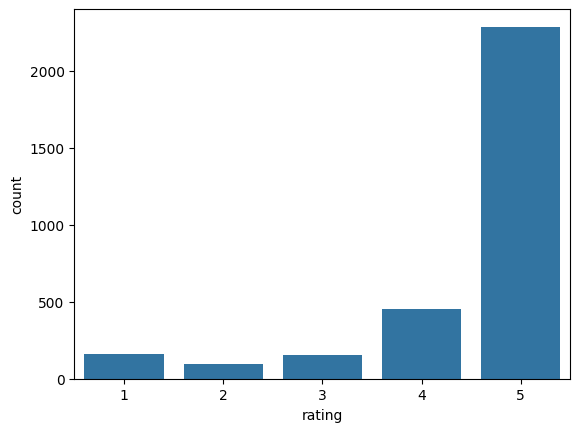

In [11]:
sns.countplot(x=reviews_df['rating'])

In [15]:
reviews_df = reviews_df.dropna(subset=["verified_reviews"])

In [22]:
reviews_df["length"] = reviews_df["verified_reviews"].apply(len)
display(reviews_df.head())

,rating,date,variation,verified_reviews,feedback,length
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1,13
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1,9
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1,195
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1,172
4,5,31-Jul-18,Charcoal Fabric,Music,1,5


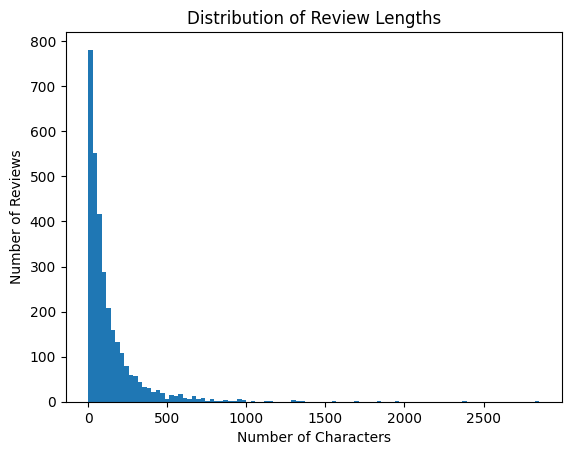

In [35]:
reviews_df['length'].plot(bins=100, kind='hist')
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Reviews')
plt.show()

In [42]:
rating_feedback_table = pd.crosstab(reviews_df['rating'], reviews_df['feedback'])
print(rating_feedback_table)

feedback    0     1
rating             
1         161     0
2          95     0
3           0   152
4           0   455
5           0  2286


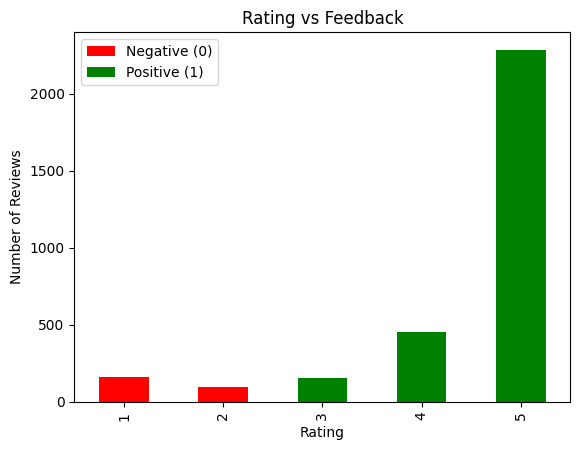

In [44]:
pd.crosstab(reviews_df['rating'], reviews_df['feedback']).plot(
    kind='bar', stacked=True, color=['red','green']
)
plt.title("Rating vs Feedback")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.legend(["Negative (0)", "Positive (1)"])
plt.show()

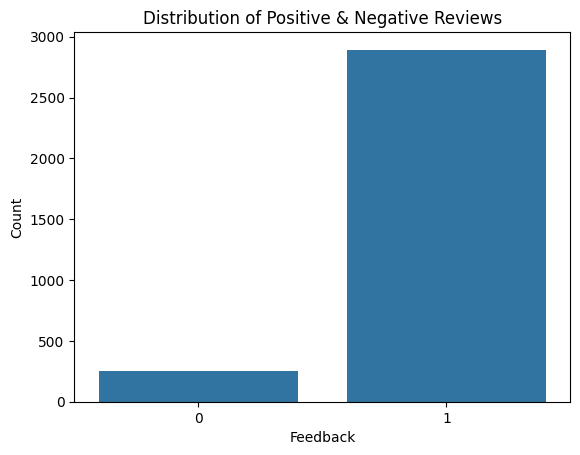

In [47]:
sns.countplot(x=reviews_df['feedback'])
plt.title('Distribution of Positive & Negative Reviews')
plt.xlabel('Feedback')
plt.ylabel('Count')
plt.show()

In [91]:
stop_words = set(stopwords.words('english'))
stop_words -= {"not", "no", "never", "n't"}
def message_cleaning(message):
    message = str(message).lower()
    message = ''.join([ char for char in message if char not in string.punctuation])
    words = [word for word in message.split() if word not in stop_words]
    return ' '.join(words)

In [92]:
message_test = "I love amazon echo very much!!! and it is the best!"
new_message = message_cleaning(message_test)
print(new_message)

love amazon echo much best


In [93]:
reviews_df['cleaned_reviews'] = reviews_df['verified_reviews'].apply(message_cleaning)
display(reviews_df[['verified_reviews', 'cleaned_reviews']].head())

,verified_reviews,cleaned_reviews
0,Love my Echo!,love echo
1,Loved it!,loved
2,"Sometimes while playing a game, you can answer...",sometimes playing game answer question correct...
3,I have had a lot of fun with this thing. My 4 ...,lot fun thing 4 yr old learns dinosaurs contro...
4,Music,music


In [101]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=30000)
X = vectorizer.fit_transform(reviews_df['cleaned_reviews'])
y = reviews_df['feedback']

print("Feature matrix shape:", X.shape)

Feature matrix shape: (3149, 9774)


In [102]:
print(vectorizer.get_feature_names_out())

['10' '10 20' '10 connect' ... 'zero' 'zigbee' 'zwave']


In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

In [104]:
print("Train:", y_train.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))


Train: feedback
1    0.918618
0    0.081382
Name: proportion, dtype: float64
Test: feedback
1    0.919048
0    0.080952
Name: proportion, dtype: float64


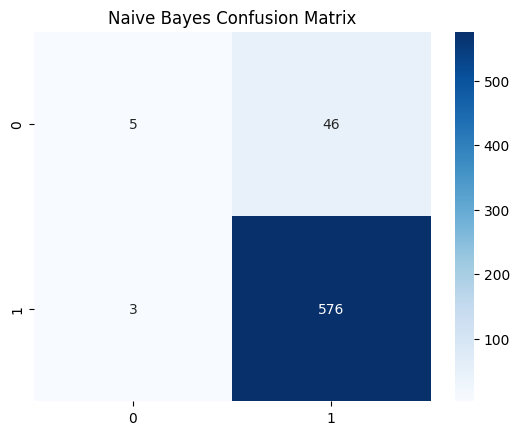

              precision    recall  f1-score   support

           0       0.62      0.10      0.17        51
           1       0.93      0.99      0.96       579

    accuracy                           0.92       630
   macro avg       0.78      0.55      0.56       630
weighted avg       0.90      0.92      0.90       630



In [ ]:
# Naive Bayes

NB_classifier = MultinomialNB(alpha=0.5)
NB_classifier.fit(X_train, y_train)

y_predict_test = NB_classifier.predict(X_test)
cm = confusion_matrix(y_test, y_predict_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Naive Bayes Confusion Matrix")
plt.show()

print(classification_report(y_test, y_predict_test, zero_division=0))


In [89]:
y_pred_nb = NB_classifier.predict(X_test)
print(np.unique(y_pred_nb, return_counts=True))

(array([1]), array([630]))


In [87]:
reviews_df["feedback"].value_counts()
reviews_df["feedback"].value_counts(normalize=True)

feedback
1    0.918704
0    0.081296
Name: proportion, dtype: float64

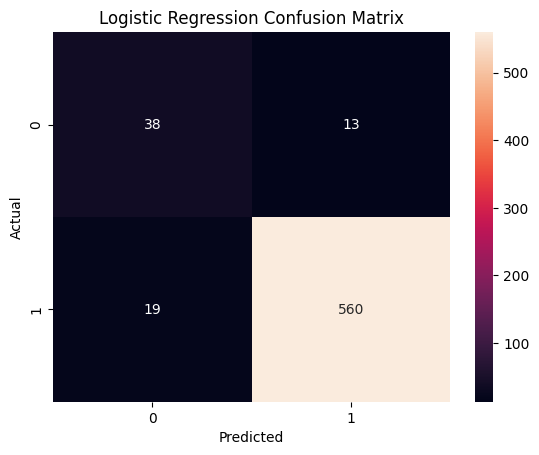

              precision    recall  f1-score   support

           0       0.67      0.75      0.70        51
           1       0.98      0.97      0.97       579

    accuracy                           0.95       630
   macro avg       0.82      0.86      0.84       630
weighted avg       0.95      0.95      0.95       630



In [111]:
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

cm_log_reg = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred_lr, zero_division=0))


In [113]:
def sentiment_label(pred):
    return "Positive" if pred == 1 else "Negative"

def predict_sentiment(review_text, model=log_reg):
    cleaned = message_cleaning(review_text)
    vect = vectorizer.transform([cleaned])
    prediction = model.predict(vect)[0]
    return sentiment_label(prediction)

print(predict_sentiment("I hate the amazon echo, I never want to see it again!"))
print(predict_sentiment("We love our amazon echo, I highly reccommend it for everyone :))"))
print(predict_sentiment("Not good, don't buy"))



Negative
Positive
Negative


In [114]:
import joblib

joblib.dump(log_reg, "sentiment_model_logreg.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("Saved model + vectorizer.")

Saved model + vectorizer.
